# Решатель

In [32]:
import sympy as sp
from sympy import latex, print_latex
from math import e, lcm, sqrt, sin, cos
import math

h1, h2 = "\n" + "="*50, "\n" + "-"*50

def geo(m):
    if m.shape[0] == 1:
        return f'[{', '.join([str(round(m[0, i], 10)) for i in range(m.shape[1])])}]'
    return f'[{'; '.join([', '.join([str(round(m[j, i], 10)) for i in range(m.shape[1])]) for j in range(m.shape[0])])}]'    

def geolin_matrix(s: str, n: int):
    s = s.replace('−', '-').replace('\u200b', '').split()
    d = sp.MutableDenseMatrix.zeros(n, len(s) // n)
    for i in range(len(s)):
        d[i % n, i // n] = int(s[i])
    return d

def geolin_vector(s: str):
    s = s.replace('−', '-').replace('\u200b', '').split()
    return sp.Matrix([int(x) for x in s])

def mat(inp):
    if isinstance(inp, list):
        return sp.Matrix(inp)
    return inp

In [33]:
def kernel(A):
    A = mat(A)
    K = sp.Matrix.hstack(*A.nullspace())
    display("Исходная матрица A:", A, "Базис ядра K:", K)
    print(geo(K.T))

In [34]:
def image(A):
    A = mat(A)
    display("Изначальная матрица")
    display(A)
    display("Приводим матрицу к ступенчатому виду")
    echelon = A.echelon_form()
    display(echelon)
    # Находим индексы ведущих столбцов
    pivot_cols = []
    for row in echelon.tolist():
        # Ищем первый ненулевой элемент в строке
        for i, elem in enumerate(row):
            if elem != 0:
                if i not in pivot_cols:
                    pivot_cols.append(i)
                break  # Переходим к следующей строке
    
    # Выбираем соответствующие столбцы из исходной матрицы
    basis_columns = [A.col(i) for i in pivot_cols]
    
    display("Формируем матрицу базиса")
    IM = sp.Matrix.hstack(*basis_columns)
    display(IM)
    print(geo(IM.T))

In [35]:
def spectrum(A_input):
    print("Исходная матрица A:")
    A = mat(A_input)
    print(A)

    lamda = sp.symbols('λ')
    print(h1)
    print("Вычисление характеристического полинома det(A - λE)")

    print("\nМатрица A - λE:")
    mat_AE = A - lamda * sp.eye(A.rows)
    print(mat_AE)

    print("\nХарактеристический полином:")
    char_poly = sp.simplify(mat_AE.det())
    char_poly_factored = sp.factor(char_poly)
    print(char_poly)
    print(char_poly_factored)

    print("\nСпектр и алгебраические кратности:")
    roots = sp.roots(char_poly_factored, lamda)
    if not roots:
        roots_list = sp.solve(char_poly, lamda)
        roots = {root: sp.root_multiplicity(char_poly_factored, root) for root in roots_list}
    eigenvalues = sorted(roots.keys(), key=lambda x: [float(sp.re(x)), float(sp.im(x))])
    for eig_val in eigenvalues:
        print(f"λ = {eig_val}, m(λ) = {roots[eig_val]}")
        
        
    print(h1)
    print("Нахождение собственных векторов и нильпотентных операторов")
    eigenvectors = []
    eigenvec_indices = []
    for j, eig_val in enumerate(eigenvalues):
        current_vectors = []
        print(f"\nДля λ = {eig_val}:")
        print(f"Нильпотентный оператор N_λ:")
        N = A - eig_val * sp.eye(A.rows)
        print(N)
        
        print("\nСобственные векторы:")
        nullspace = N.nullspace()
        if nullspace:
            for vec in nullspace:
                eigenvectors.append(vec)
                current_vectors.append(vec)
                eigenvec_indices.append(eig_val)
                print(vec.T)  # Транспонируем для компактного вывода
        else:
            print(f"ERROR: Пустой базис собственных векторов числа {eig_val}!")
        
        alg_mult, geo_mult = roots[eig_val], len(nullspace)
        print(f"0 < g(λ) = {geo_mult} ≤ m(λ) = {alg_mult}")
        
        if alg_mult > geo_mult:
            print("Нужен поиск присоединённых векторов!")
        
        if j + 1 < len(eigenvalues):
            print(h2)

    print(h1)
    print("Матрица перехода C")
    C = sp.Matrix.hstack(*eigenvectors)
    print(C)
    
    if C.cols == C.rows:
        print("\nОбратная матрица C^(-1)")
        print(C.inv())
    return A, C, eigenvec_indices, eigenvalues

def jordan(A, C):
    A, C = mat(A), mat(C)
    if C.cols != C.rows:
        return
    C_inv = C.inv()
    
    print(h1)
    print("Матрица ЖНФ J")
    J = C_inv @ A @ C
    print(J)
    return J

def proectors(C, eigenvec_indices, eigenvalues):
    C = mat(C)
    if C.cols != C.rows:
        return None
    C_inv = C.inv()
    
    print(h1)
    print("Вычисляем проекторы")
    P = {}
    for j, eig_val in enumerate(eigenvalues):
        print(f"\nДля λ = {eig_val}:")
        Pi = []
        for i in range(C.cols):
            if eigenvec_indices[i] == eig_val:
                print(f"Проектор {i} вектора Pi=v*E*f:")
                v, f = C[:,i], C_inv[i,:]
                print('v = ', C[:,i])
                print('f = ', C_inv[i,:])
                PP = v @ f
                print(PP)
                Pi.append(PP)
        print(f"Проектор для λ = {eig_val}")
        P[eig_val] = sp.zeros(C.cols)
        for p in Pi:
            P[eig_val] += p
        print(P[eig_val])
        
        if j + 1 < len(eigenvalues):
            print(h2)  
    return P

# КР 2

Задача 1

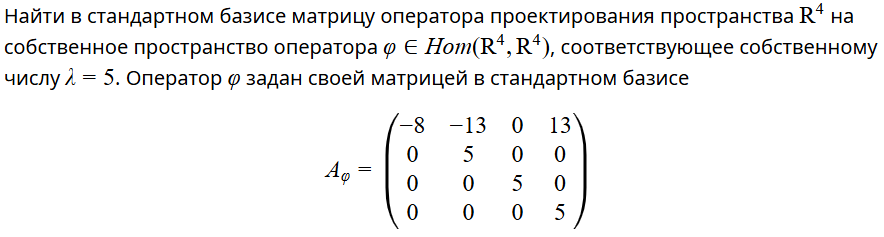

In [36]:
A_input = geolin_matrix("−8 0 0 0 ​ −13 5 0 0 ​ 0 0 5 0 ​ 13 0 0 5 ​ ​ ​", 4)
A, C, eigenvec_indices, eigenvalues = spectrum(A_input)
J = jordan(A, C)
P = proectors(C, eigenvec_indices, eigenvalues)

p = P[5]
display(p)
print(geo(p))

Исходная матрица A:
Matrix([[-8, -13, 0, 13], [0, 5, 0, 0], [0, 0, 5, 0], [0, 0, 0, 5]])

Вычисление характеристического полинома det(A - λE)

Матрица A - λE:
Matrix([[-λ - 8, -13, 0, 13], [0, 5 - λ, 0, 0], [0, 0, 5 - λ, 0], [0, 0, 0, 5 - λ]])

Характеристический полином:
(λ - 5)**3*(λ + 8)
(λ - 5)**3*(λ + 8)

Спектр и алгебраические кратности:
λ = -8, m(λ) = 1
λ = 5, m(λ) = 3

Нахождение собственных векторов и нильпотентных операторов

Для λ = -8:
Нильпотентный оператор N_λ:
Matrix([[0, -13, 0, 13], [0, 13, 0, 0], [0, 0, 13, 0], [0, 0, 0, 13]])

Собственные векторы:
Matrix([[1, 0, 0, 0]])
0 < g(λ) = 1 ≤ m(λ) = 1

--------------------------------------------------

Для λ = 5:
Нильпотентный оператор N_λ:
Matrix([[-13, -13, 0, 13], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]])

Собственные векторы:
Matrix([[-1, 1, 0, 0]])
Matrix([[0, 0, 1, 0]])
Matrix([[1, 0, 0, 1]])
0 < g(λ) = 3 ≤ m(λ) = 3

Матрица перехода C
Matrix([[1, -1, 0, 1], [0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1]])

Обратная матри

Matrix([
[0, -1, 0, 1],
[0,  1, 0, 0],
[0,  0, 1, 0],
[0,  0, 0, 1]])

[0, -1, 0, 1; 0, 1, 0, 0; 0, 0, 1, 0; 0, 0, 0, 1]


Задача 2

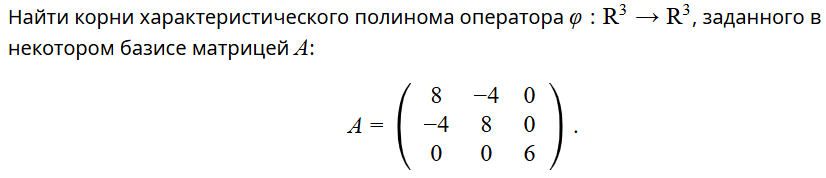

In [37]:
A = geolin_matrix("8 −4 0 ​ −4 8 0 ​ 0 0 6 ​", 3)

A, C, eigenvec_indices, eigenvalues = spectrum(A)
J = jordan(A, C)
P = proectors(C, eigenvec_indices, eigenvalues)

display('Answer')
print(f'[{', '.join(map(str, sorted(eigenvalues)))}]')

Исходная матрица A:
Matrix([[8, -4, 0], [-4, 8, 0], [0, 0, 6]])

Вычисление характеристического полинома det(A - λE)

Матрица A - λE:
Matrix([[8 - λ, -4, 0], [-4, 8 - λ, 0], [0, 0, 6 - λ]])

Характеристический полином:
-λ**3 + 22*λ**2 - 144*λ + 288
-(λ - 12)*(λ - 6)*(λ - 4)

Спектр и алгебраические кратности:
λ = 4, m(λ) = 1
λ = 6, m(λ) = 1
λ = 12, m(λ) = 1

Нахождение собственных векторов и нильпотентных операторов

Для λ = 4:
Нильпотентный оператор N_λ:
Matrix([[4, -4, 0], [-4, 4, 0], [0, 0, 2]])

Собственные векторы:
Matrix([[1, 1, 0]])
0 < g(λ) = 1 ≤ m(λ) = 1

--------------------------------------------------

Для λ = 6:
Нильпотентный оператор N_λ:
Matrix([[2, -4, 0], [-4, 2, 0], [0, 0, 0]])

Собственные векторы:
Matrix([[0, 0, 1]])
0 < g(λ) = 1 ≤ m(λ) = 1

--------------------------------------------------

Для λ = 12:
Нильпотентный оператор N_λ:
Matrix([[-4, -4, 0], [-4, -4, 0], [0, 0, -6]])

Собственные векторы:
Matrix([[-1, 1, 0]])
0 < g(λ) = 1 ≤ m(λ) = 1

Матрица перехода C
M

'Answer'

[4, 6, 12]


Задача 3

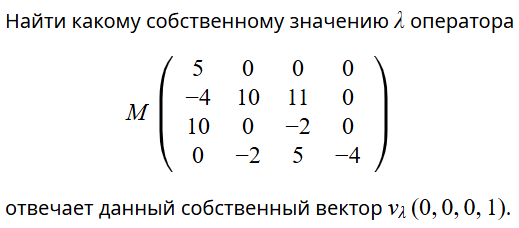

In [38]:
M = geolin_matrix("5 −4 10 0 ​ 0 10 0 −2 ​ 0 11 −2 5 ​ 0 0 0 −4 ​ ​ ​​", 4)
v = sp.Matrix([0, 0, 0, 1])
lv = M @ v
display(lv)
print(lv[3] / v[3])

Matrix([
[ 0],
[ 0],
[ 0],
[-4]])

-4


Задача 4

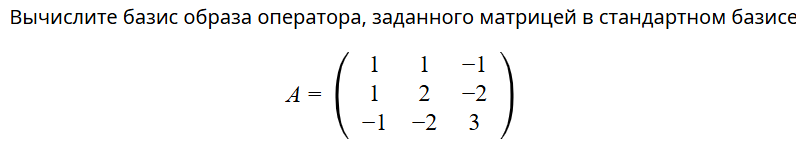

In [39]:
image(geolin_matrix("1 1 −1 1 2 −2 −1 −2 3​", 3))

'Изначальная матрица'

Matrix([
[ 1,  1, -1],
[ 1,  2, -2],
[-1, -2,  3]])

'Приводим матрицу к ступенчатому виду'

Matrix([
[1, 1, -1],
[0, 1, -1],
[0, 0,  1]])

'Формируем матрицу базиса'

Matrix([
[ 1,  1, -1],
[ 1,  2, -2],
[-1, -2,  3]])

[1, 1, -1; 1, 2, -2; -1, -2, 3]


Задача 5

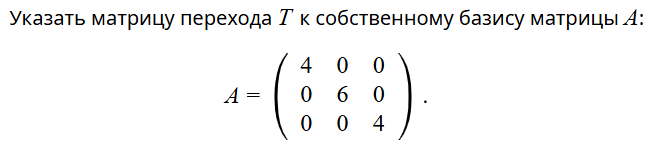

In [47]:
A = geolin_matrix("4 0 0 ​ 0 6 0 ​ 0 0 4 ​ ", 3)

A, T, eigenvec_indices, eigenvalues = spectrum(A)
J = jordan(A, T)
P = proectors(T, eigenvec_indices, eigenvalues)

display(T)
print(geo(T))

display(A.jordan_form())

Исходная матрица A:
Matrix([[4, 0, 0], [0, 6, 0], [0, 0, 4]])

Вычисление характеристического полинома det(A - λE)

Матрица A - λE:
Matrix([[4 - λ, 0, 0], [0, 6 - λ, 0], [0, 0, 4 - λ]])

Характеристический полином:
-λ**3 + 14*λ**2 - 64*λ + 96
-(λ - 6)*(λ - 4)**2

Спектр и алгебраические кратности:
λ = 4, m(λ) = 2
λ = 6, m(λ) = 1

Нахождение собственных векторов и нильпотентных операторов

Для λ = 4:
Нильпотентный оператор N_λ:
Matrix([[0, 0, 0], [0, 2, 0], [0, 0, 0]])

Собственные векторы:
Matrix([[1, 0, 0]])
Matrix([[0, 0, 1]])
0 < g(λ) = 2 ≤ m(λ) = 2

--------------------------------------------------

Для λ = 6:
Нильпотентный оператор N_λ:
Matrix([[-2, 0, 0], [0, 0, 0], [0, 0, -2]])

Собственные векторы:
Matrix([[0, 1, 0]])
0 < g(λ) = 1 ≤ m(λ) = 1

Матрица перехода C
Matrix([[1, 0, 0], [0, 0, 1], [0, 1, 0]])

Обратная матрица C^(-1)
Matrix([[1, 0, 0], [0, 0, 1], [0, 1, 0]])

Матрица ЖНФ J
Matrix([[4, 0, 0], [0, 4, 0], [0, 0, 6]])

Вычисляем проекторы

Для λ = 4:
Проектор 0 вектора P

Matrix([
[1, 0, 0],
[0, 0, 1],
[0, 1, 0]])

[1, 0, 0; 0, 0, 1; 0, 1, 0]


(Matrix([
 [1, 0, 0],
 [0, 0, 1],
 [0, 1, 0]]),
 Matrix([
 [4, 0, 0],
 [0, 4, 0],
 [0, 0, 6]]))

Задача 6

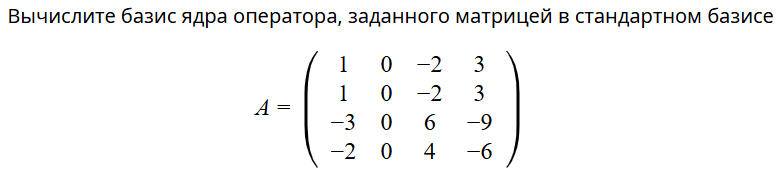

In [48]:
kernel(geolin_matrix("1 1 −3 −2 ​ 0 0 0 0 ​ −2 −2 6 4 ​ 3 3 −9 −6 ​ ​ ​", 4))

'Исходная матрица A:'

Matrix([
[ 1, 0, -2,  3],
[ 1, 0, -2,  3],
[-3, 0,  6, -9],
[-2, 0,  4, -6]])

'Базис ядра K:'

Matrix([
[0, 2, -3],
[1, 0,  0],
[0, 1,  0],
[0, 0,  1]])

[0, 1, 0, 0; 2, 0, 1, 0; -3, 0, 0, 1]


Задача 7

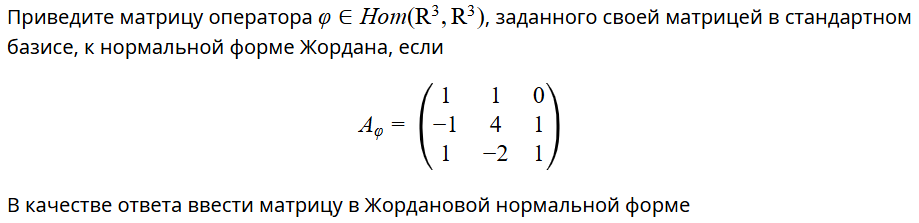

In [50]:
A_input = geolin_matrix("1 −1 1 ​ 1 4 −2 ​ 0 1 1", 3)
A, C, eigenvec_indices, eigenvalues = spectrum(A_input)
# J = jordan(A, C)
# P = proectors(C, eigenvec_indices, eigenvalues)

T, J = A.jordan_form()
display(T, J)
print(geo(J))

Исходная матрица A:
Matrix([[1, 1, 0], [-1, 4, 1], [1, -2, 1]])

Вычисление характеристического полинома det(A - λE)

Матрица A - λE:
Matrix([[1 - λ, 1, 0], [-1, 4 - λ, 1], [1, -2, 1 - λ]])

Характеристический полином:
-λ**3 + 6*λ**2 - 12*λ + 8
-(λ - 2)**3

Спектр и алгебраические кратности:
λ = 2, m(λ) = 3

Нахождение собственных векторов и нильпотентных операторов

Для λ = 2:
Нильпотентный оператор N_λ:
Matrix([[-1, 1, 0], [-1, 2, 1], [1, -2, -1]])

Собственные векторы:
Matrix([[-1, -1, 1]])
0 < g(λ) = 1 ≤ m(λ) = 3
Нужен поиск присоединённых векторов!

Матрица перехода C
Matrix([[-1], [-1], [1]])


Matrix([
[ 1,  1, 0],
[ 1,  2, 1],
[-1, -2, 0]])

Matrix([
[2, 1, 0],
[0, 2, 1],
[0, 0, 2]])

[2, 1, 0; 0, 2, 1; 0, 0, 2]


Задача 8

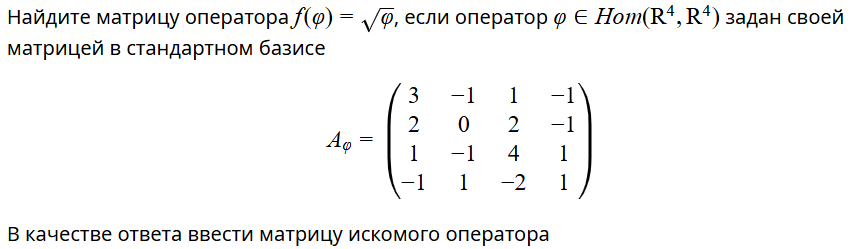

In [51]:
A_input = geolin_matrix("3 2 1 −1 ​ −1 0 −1 1 ​ 1 2 4 −2 ​ −1 −1 1 1 ​ ​ ​", 4)
A, C, eigenvec_indices, eigenvalues = spectrum(A_input)
# J = jordan(A, C)
# P = proectors(C, eigenvec_indices, eigenvalues)

T, J = A.jordan_form()
display(T, J)

Исходная матрица A:
Matrix([[3, -1, 1, -1], [2, 0, 2, -1], [1, -1, 4, 1], [-1, 1, -2, 1]])

Вычисление характеристического полинома det(A - λE)

Матрица A - λE:
Matrix([[3 - λ, -1, 1, -1], [2, -λ, 2, -1], [1, -1, 4 - λ, 1], [-1, 1, -2, 1 - λ]])

Характеристический полином:
λ**4 - 8*λ**3 + 24*λ**2 - 32*λ + 16
(λ - 2)**4

Спектр и алгебраические кратности:
λ = 2, m(λ) = 4

Нахождение собственных векторов и нильпотентных операторов

Для λ = 2:
Нильпотентный оператор N_λ:
Matrix([[1, -1, 1, -1], [2, -2, 2, -1], [1, -1, 2, 1], [-1, 1, -2, -1]])

Собственные векторы:
Matrix([[1, 1, 0, 0]])
0 < g(λ) = 1 ≤ m(λ) = 4
Нужен поиск присоединённых векторов!

Матрица перехода C
Matrix([[1], [1], [0], [0]])


Matrix([
[1,  3,  1, 0],
[1,  4,  2, 0],
[0,  1,  2, 1],
[0, -1, -2, 0]])

Matrix([
[2, 1, 0, 0],
[0, 2, 1, 0],
[0, 0, 2, 1],
[0, 0, 0, 2]])

In [52]:
N = sp.Matrix([[1, -1, 1, -1], [2, -2, 2, -1], [1, -1, 2, 1], [-1, 1, -2, -1]])
a, b = sp.symbols("α β")
B = sp.Matrix([a + b, a + 2*b, a + b, b])

sp.linsolve(N.row_join(B))

EmptySet

In [45]:
C = sp.Matrix([
    [1, 1, -1, 0],
    [1, 2, -1, 1/2],
    [1, 1, 0, -1/2],
    [0, 1, 0, 1]
])

display(C.inv() @ A @ C)

Matrix([
[-3.0,  1.0,    0,   0],
[   0, -3.0,  1.0,   0],
[   0,    0, -3.0,   0],
[   0,    0,    0, 2.0]])

In [46]:
T, J = A.jordan_form()

FJ = sp.Matrix([
    [sin(-3), cos(-3), -0.5*sin(-3), 0],
    [0, sin(-3), cos(-3), 0],
    [0, 0, sin(-3), 0],
    [0, 0, 0, sin(2)]
])

display(FJ)
F = T @ FJ @ T.inv()
display(F)
print(geo(F))

Matrix([
[-0.141120008059867, -0.989992496600445, 0.0705600040299336,                 0],
[                 0, -0.141120008059867, -0.989992496600445,                 0],
[                 0,                  0, -0.141120008059867,                 0],
[                 0,                  0,                  0, 0.909297426825682]])

Matrix([
[ 1.83886498514102,   -1.06055250063038, -0.919432492570512, 0.0705600040299335],
[ 3.03040242808644,   -1.26209744697535,  -1.90942498917096,  0.130984942315037],
[0.929567558315342, -0.0101350657448299,  -1.06055250063038, -0.979857430855615],
[  2.1008348697711,   -1.11084237317065, -0.989992496600445,  0.969722365110785]])

[1.8388649851, -1.0605525006, -0.9194324926, 0.0705600040; 3.0304024281, -1.2620974470, -1.9094249892, 0.1309849423; 0.9295675583, -0.0101350657, -1.0605525006, -0.9798574309; 2.1008348698, -1.1108423732, -0.9899924966, 0.9697223651]
